In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df_dirty = pd.read_csv("dirty_dataset.csv")
df = df_dirty.copy()

<h1 style='color: red'>Task 5 : Numeric Stored as String</h1>

I am going for the task 5 because to fill the NaN cells I need to compute mean, median or mode. So making the float will help me to do that.

In [54]:
print(df['salary'].dtypes)
print(df['weight_kg'].dtypes)
print(df['price'].dtypes)

object
object
object


I can see salary, weight_kg and price colums are in object type, So I need to make them float

In [55]:
#for salary column
df['salary'] = df['salary'].str.replace('$', '', regex=False).str.replace(',', '', regex=False)
df['salary'] = pd.to_numeric(df['salary'], errors='coerce')
#here $ and , are removed and then converted to float
#for weight_kg column
df['weight_kg'] = df['weight_kg'].str.replace('kg', '', regex=False)
df['weight_kg'] = pd.to_numeric(df['weight_kg'], errors='coerce')
#here kg is removed and then converted to float
#for price column
df['price'] = df['price'].str.replace('$', '', regex=False).str.replace(',', '', regex=False)
df['price'] = pd.to_numeric(df['price'], errors='coerce')
#here $ and , are removed and then converted to float

Now again check for their dtypes

In [56]:
print(df['salary'].dtypes)
print(df['weight_kg'].dtypes)
print(df['price'].dtypes)

float64
float64
float64


As all of them are converted into float64 and errors are also handled.

<h1 style='color: red'>Task 9 : Invalid Values</h1>

Now going for the task 9 because to find median. So I will make the invalid cells to NaN

In [57]:
#Counting the number of invalid entries in age and price column
print(df[(df['age']<18) | (df['age']>65)].shape)
print(df[(df['price']<0)].shape)

(398, 15)
(398, 15)


In [58]:
#Now making the invalid entries to NaN
df.loc[(df['age']<18) | (df['age']>65), 'age'] = np.nan
df.loc[df['price']<0, 'price'] = np.nan

In [59]:
#Checking again the number of invalid entries in age and price column
print(df[(df['age']<18) | (df['age']>65)].shape)
print(df[(df['price']<0)].shape)

(0, 15)
(0, 15)


Here one line in the assignment said that the NaN cells have to be filld out with median but this same task I will also do in Task 1. So to reduce redundancy I skipped this for task 9.

<h1 style='color: red'>Task 2 : Duplicate Rows</h1>

Here I am going for task 2, it may reduce the size pf df and make the operations faster. I should have gone for it first. Sorry vaiiiiii

In [60]:
df.duplicated().sum()
df.shape

(20300, 15)

In [61]:
df[df.duplicated()]
df.drop_duplicates(inplace=True)

In [62]:
#now printing the final shape of the cleaned dataset
print(df.shape)

(20000, 15)


As per I see 300 rows got dropped. So the task 2 is finished.

<h1 style='color: red'>Task 3 : Duplicate IDs</h1>

In [63]:
#Count the duplicate IDs
print(df['employee_id'].duplicated().sum())
#199 is the output because 300 were duplicate rows that I removes before
#Now see which rows are actually involved in duplicates(IDs)
print(df[df['employee_id'].duplicated(keep=False)])

199
       employee_id        name   age    salary   join_date   department  \
29             250    Frank U.  56.0   90635.0  2013-05-12        Sales   
40              49     John L.  58.0   50810.0  2024-07-22           hr   
75              48      Ira E.   NaN  101013.0  2013-08-28  engineering   
196            436  Charlie S.  29.0   54295.0  2020-08-27     Mrketing   
270             86      Bob U.  36.0   61688.0  2012/11/23  engineering   
...            ...         ...   ...       ...         ...          ...   
20016          207      Bob M.  63.0   73657.0  2013-10-08     Mrketing   
20072          435  Charlie U.  31.0  112727.0  2016-04-15  engineering   
20104          427    Frank U.  33.0   35686.0  2014-03-21     Mrketing   
20267           35      Eve L.  55.0   40160.0  2015-12-13      Finance   
20289          289    Frank C.  58.0   95829.0  2011-10-28           HR   

       gender        country         city  weight_kg is_active  \
29       male     Bangladesh 

In [64]:
#now I am going for option B, because I don't want to lose information. So assign them a different ID will solve the problem
df['employee_id'] = range(1, len(df) + 1)

In [65]:
#Now check the duplicates IDs count again
print(df['employee_id'].duplicated().sum())

0


As 0 is the result so every duplicate Id got handled

<h1 style='color: red'>Task 4 : Wrong Date Formats</h1>

In [66]:
df['join_date'].dtypes

dtype('O')

In [67]:
df['join_date'] = pd.to_datetime(df['join_date'], errors='coerce')
#converetd into datetime format, errors='coerce' will convert invalid dates to NaT
df['join_date'] = df['join_date'].fillna(df['join_date'].median())
#NaT values are replaced with median date of the column
df['join_date'] = df['join_date'].dt.strftime('%Y-%m-%d').astype('datetime64[ns]')
#strftime is used to format the date into 'YYYY-MM-DD' format and then converted back to datetime64[ns] type

In [68]:
#for checking the data type is datetime64 or not
df['join_date'].dtypes

dtype('<M8[ns]')

Here a important fact that if any datetime has month and date both less then 13, the pandas will consider the  first number as month. I kept it as default as it is a ambiguity problem

<h1 style='color: red'>Task 11 : Boolean as String</h1>

In [69]:
df['is_active'].unique()
#it will print all the unique values that used to define true false in the data set
df['is_active'].dtypes

dtype('O')

In [70]:
#Define a truthy_set
truthy_set = ["1", "TRUE"] #I skipped "true", "t", "T", etc because it is not in the dataset
df['is_active'] = df['is_active'].isin(truthy_set)

In [71]:
#Now check for the final datatype of is_active column
df['is_active'].dtypes

dtype('bool')

AS dtype is bool for is_active now, the task 11 is also finished

<h1 style='color: red'>Task 13 : Range Violation</h1>

For age column I have already set the 18 to 65 range in task 9. So the count for invalid ages will be 0 here. I will fill them in task 1 with their Median. 

In [72]:
ranges = {
    'age': (18, 65),
    'price': (0, 10000),
    'salary': (15000, 500000)
}
#count age violations (must be 0 here because it was handled before)
df[(df['age'] < ranges['age'][0]) | (df['age'] > ranges['age'][1])].shape

(0, 15)

In [73]:
#Now count violations in price column
df[(df['price'] < ranges['price'][0]) | (df['price'] > ranges['price'][1])].shape

(0, 15)

In [74]:
#Now count violations in salary column
df[(df['salary'] < ranges['salary'][0]) | (df['salary'] > ranges['salary'][1])].shape

(577, 15)

In [75]:
#Here I will make the range violated cells into NaN
df.loc[(df['age'] < ranges['age'][0]) | (df['age'] > ranges['age'][1]), 'age'] = np.nan
df.loc[(df['price'] < ranges['price'][0]) | (df['price'] > ranges['price'][1]), 'price'] = np.nan
df.loc[(df['salary'] < ranges['salary'][0]) | (df['salary'] > ranges['salary'][1]), 'salary'] = np.nan

In [76]:
#Now verify the final dataset
print(df[(df['age'] < ranges['age'][0]) | (df['age'] > ranges['age'][1])].shape)
print(df[(df['price'] < ranges['price'][0]) | (df['price'] > ranges['price'][1])].shape)
print(df[(df['salary'] < ranges['salary'][0]) | (df['salary'] > ranges['salary'][1])].shape)

(0, 15)
(0, 15)
(0, 15)


Now as there are 0 rows, the task 13 got finished.

<h1 style='color: red'>Task 10 : Noisy Text (Reviews)</h1>

In [77]:
df['review'].value_counts()

review
Delivery was fast and packaging great.    2792
Good value for money.                     2767
Product met all expectations.             2760
Excellent product, highly recommend!      2748
Would buy again without hesitation.       2725
Very satisfied with the quality.          2720
ok                                         250
...                                        243
ok ok                                      235
bad                                        233
na                                         232
good                                       223
fine                                       220
.                                          217
not bad                                    193
Name: count, dtype: int64

In [78]:
#making noisy list
noise = ["ok", "...", "ok ok", "bad", "na", "good", "fine", ".", "not bad"]
df['review'] = df['review'].replace(noise, np.nan)
df['review'].replace('', np.nan, inplace=True)

/tmp/ipykernel_2982/2092073602.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['review'].replace('', np.nan, inplace=True)


In [79]:
#verifying
df['review'].str.split().str.len().value_counts()

review
4.0    8275
5.0    5445
6.0    2792
Name: count, dtype: int64

<h1 style='color: red'>Task 12 : Data Type Issue</h1>

In [80]:
df.dtypes

employee_id                     int64
name                           object
age                           float64
salary                        float64
join_date              datetime64[ns]
department                     object
gender                         object
country                        object
city                           object
weight_kg                     float64
is_active                        bool
review                         object
price                         float64
weight_kg_duplicate           float64
target                          int64
dtype: object

Here all the data types are correct for each column because I have implemented them in previous tasks. And as they are correct so now nothing to do with them. Left them as it is may best practice.

<h1 style='color: red'>Task 6 : Inconsistent Labels</h1>

In [81]:
#checking for country first
df['country'].value_counts()

country
USA               1528
usa               1526
U.K.              1521
BD                1513
Bangladesh        1509
U.S.A             1503
us                1499
UK                1493
United States     1480
America           1479
BANGLADESH        1473
bd                1447
United Kingdom    1431
Name: count, dtype: int64

In [82]:
#making a mapping dictionary for country column
country_mapping = {
    'USA': 'United States',
    'usa': 'United States',
    'U.K.': 'United Kingdom',
    'BD': 'Bangladesh',
    'U.S.A': 'United States',
    'Bangladesh': 'Bangladesh',
    'us': 'United States',
    'UK': 'United Kingdom',
    'United States': 'United States',
    'America': 'United States',
    'BANGLADESH': 'Bangladesh',
    'bd': 'Bangladesh',
    'United Kingdom': 'United Kingdom'
}
df['country'] = df['country'].map(country_mapping).fillna(df['country'])
#map function is used to replace the values in country column based on the mapping dictionary, fillna is used to keep the original value if it is not found in the mapping dictionary

In [83]:
#verifying the final country column
print(df['country'].value_counts())

country
United States     9015
Bangladesh        5942
United Kingdom    4445
Name: count, dtype: int64


In [84]:
#noe checking for the gender column
df['gender'].value_counts()

gender
M         1928
Woman     1868
male      1854
Man       1847
Female    1845
Male      1837
MALE      1820
female    1817
F         1801
FEMALE    1772
Name: count, dtype: int64

In [85]:
#here making all columns lowercase to handle the case sensitivity then will  take mapping dict
df['gender'] = df['gender'].str.lower()
df['gender'].value_counts()

gender
male      5511
female    5434
m         1928
woman     1868
man       1847
f         1801
Name: count, dtype: int64

In [86]:
gender_mapping = {
    'male': 'male',
    'female': 'female',
    'm': 'male',
    'woman': 'female',
    'man': 'male',
    'f': 'female',
}
df['gender'] = df['gender'].map(gender_mapping).fillna(df['gender'])
#map function is used to replace the values in gender
#noe verifying the final gender column
print(df['gender'].value_counts())

gender
male      9286
female    9103
Name: count, dtype: int64


In [87]:
#now for department column
df['department'].value_counts()

department
Sales          1965
Engineering    1944
hr             1923
Finace         1921
Mrketing       1919
HR             1916
Marketing      1913
SALES          1889
engineering    1886
Finance        1882
Name: count, dtype: int64

In [88]:
department_mapping = {
    'Sales': 'sales',
    'Engineering': 'engineering',
    'hr': 'hr',
    'Finace': 'finance',
    'Mrketing': 'marketing',
    'HR': 'hr',
    'Marketing': 'marketing',
    'SALES': 'sales',
    'engineering': 'engineering',
    'Finance': 'finance'
}
df['department'] = df['department'].map(department_mapping).fillna(df['department'])
#map function is used to replace the values in department
#noe verifying the final department column
print(df['department'].value_counts())

department
sales          3854
hr             3839
marketing      3832
engineering    3830
finance        3803
Name: count, dtype: int64


Here country and gender column got fixed and departmrnt is also fixed and also make the spellings correct

<h1 style='color: red'>Task 7 : Spelling Mistakes</h1>

In [89]:
df['city'].value_counts()

city
Khulna         3752
Rajshahi       3281
Sylhet         3227
Dhaka          3124
Chittagong     3113
Slyhet          514
Dhka            488
Rajshai         485
Chitagong       474
Chittagongg     473
Dhakka          472
Name: count, dtype: int64

In [90]:
city_mapping = {
    'Slyhet': 'Sylhet',
    'Dhka': 'Dhaka',
    'Rajshai': 'Rajshahi',
    'Chitagong': 'Chittagong',
    'Chittagongg': 'Chittagong',
    'Dhakka': 'Dhaka'
}
df['city'] = df['city'].map(city_mapping).fillna(df['city'])
df['city'].value_counts()

city
Dhaka         4084
Chittagong    4060
Rajshahi      3766
Khulna        3752
Sylhet        3741
Name: count, dtype: int64

Here no need for department column because I have completed it in task 6

<h1 style='color: red'>Task 8 : Outliers</h1>

In [91]:
df['salary'].describe()

count     18822.000000
mean      74518.838859
std       25776.908249
min       30000.000000
25%       52095.000000
50%       74322.000000
75%       96478.500000
max      119998.000000
Name: salary, dtype: float64

<Axes: >

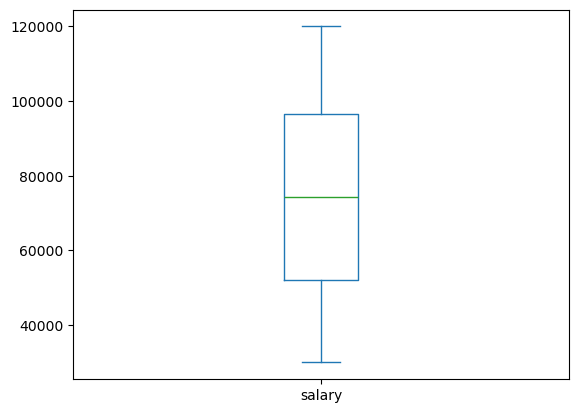

In [92]:
df['salary'].plot(kind='box')

In [93]:
Q1 = df['salary'].quantile(0.25)
Q3 = df['salary'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
#Now identifying the outliers in salary column
outliers = df[(df['salary'] < lower_bound) | (df['salary'] > upper_bound)]
#now cap it
df['salary'] = df['salary'].clip(lower = lower_bound, upper = upper_bound)
df['salary'].describe()

count     18822.000000
mean      74518.838859
std       25776.908249
min       30000.000000
25%       52095.000000
50%       74322.000000
75%       96478.500000
max      119998.000000
Name: salary, dtype: float64

Here I gone for range violation before this task, so here now no extreme outliers

<h1 style='color: red'>Task 15 : Schema / Column Validation</h1>

In [94]:
df.isnull().mean()

employee_id            0.00000
name                   0.00000
age                    0.04995
salary                 0.05890
join_date              0.00000
department             0.04210
gender                 0.08055
country                0.02990
city                   0.02985
weight_kg              0.03160
is_active              0.00000
review                 0.17440
price                  0.04190
weight_kg_duplicate    1.00000
target                 0.00000
dtype: float64

In [95]:
#drop columns will more than 50% missing values
cols_to_drop = df.columns[df.isnull().mean() > 0.5]
df.drop(columns=cols_to_drop, inplace=True)
#now verify
print(df.isnull().mean())
df.shape

employee_id    0.00000
name           0.00000
age            0.04995
salary         0.05890
join_date      0.00000
department     0.04210
gender         0.08055
country        0.02990
city           0.02985
weight_kg      0.03160
is_active      0.00000
review         0.17440
price          0.04190
target         0.00000
dtype: float64


(20000, 14)

Here one column got dropped, which is weight_kg_duplicate

<h1 style='color: red'>Task 1 : Missing Values (NaN, Empty Strings)</h1>

In [96]:
df.isnull().sum()

employee_id       0
name              0
age             999
salary         1178
join_date         0
department      842
gender         1611
country         598
city            597
weight_kg       632
is_active         0
review         3488
price           838
target            0
dtype: int64

In [97]:
#for age, salary, price, weight_kg
numeric_cols = ['age', 'salary', 'price', 'weight_kg']
for col in numeric_cols:
    median_value = df[col].median()
    df[col].fillna(median_value, inplace=True)
#now categorical columns
categorical_cols = ['city', 'country', 'department', 'gender']
for col in categorical_cols:
    mode_value = df[col].mode()[0]
    df[col].fillna(mode_value, inplace=True)
#now for date column with forward fill
df['join_date'] = df['join_date'].ffill()
#now for review column
df['review'] = df['review'].fillna('No Review')
#now for is_active column
df['is_active'] = df['is_active'].fillna(False)

/tmp/ipykernel_2982/3717795226.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_value, inplace=True)
/tmp/ipykernel_2982/3717795226.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using

In [98]:
#now time for verifying
df.isnull().sum()

employee_id    0
name           0
age            0
salary         0
join_date      0
department     0
gender         0
country        0
city           0
weight_kg      0
is_active      0
review         0
price          0
target         0
dtype: int64

Here now all the columns missing values got 0, so task 1 got finished

<h1 style='color: red'>Task 14 : Class Imbalance</h1>

In [99]:
print(df['target'].value_counts())
print()
print(df['target'].value_counts(normalize=True))

target
0    19001
1      999
Name: count, dtype: int64

target
0    0.95005
1    0.04995
Name: proportion, dtype: float64


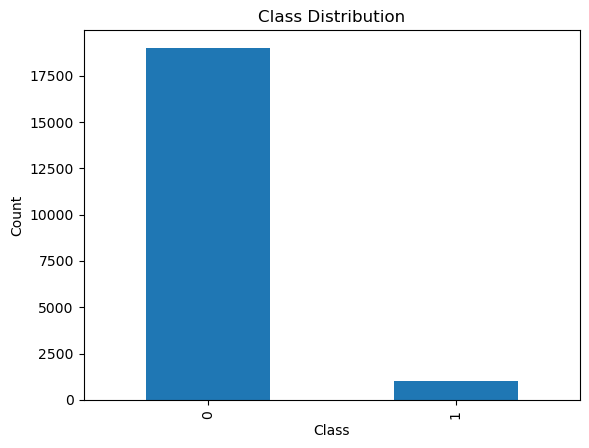

In [100]:
#visualize it
df['target'].value_counts().plot(kind = 'bar')
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [101]:
#going for solution 1
from imblearn.over_sampling import RandomOverSampler

X = df.drop('target', axis=1)
y = df['target']

ros = RandomOverSampler(random_state=42)

X_res, y_res = ros.fit_resample(X, y)

In [102]:
#verify
print(pd.Series(y_res).value_counts())
print()
print(pd.Series(y_res).value_counts(normalize=True))

target
0    19001
1    19001
Name: count, dtype: int64

target
0    0.5
1    0.5
Name: proportion, dtype: float64


In [ ]:
#making df resampled not a good practice but added here for fun
df_resampled = pd.concat([
    pd.DataFrame(X_res),
    pd.Series(y_res, name='target')
], axis=1)

df = df_resampled

In [105]:
df.shape

(38002, 14)

<h1 style='color: red'>Now let make df a csv</h1>

In [106]:
df.to_csv("Clean_dataset.csv", index = False)